<a href="https://colab.research.google.com/github/siddhi-c19/ITA-Assignment/blob/main/ITA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('/content/student_performance_dataset.xlsx')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

# Print a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Check for any missing values in each column and display their counts
print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the DataFrame:
   studytime  attendance  absences  G1  G2  failures  G3
0          1          94         1  11  11         2  11
1          1          76         6  11  12         0  13
2          3          69        14  10  11         2  10
3          1          79         6  12  13         0  12
4          3          81         2  15  14         1  15

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   studytime   200 non-null    int64
 1   attendance  200 non-null    int64
 2   absences    200 non-null    int64
 3   G1          200 non-null    int64
 4   G2          200 non-null    int64
 5   failures    200 non-null    int64
 6   G3          200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

Missing values per column:
studytime     0
attendance    0
absences      0
G1            0
G2            0
failures

## Exploratory Data Analysis (EDA)




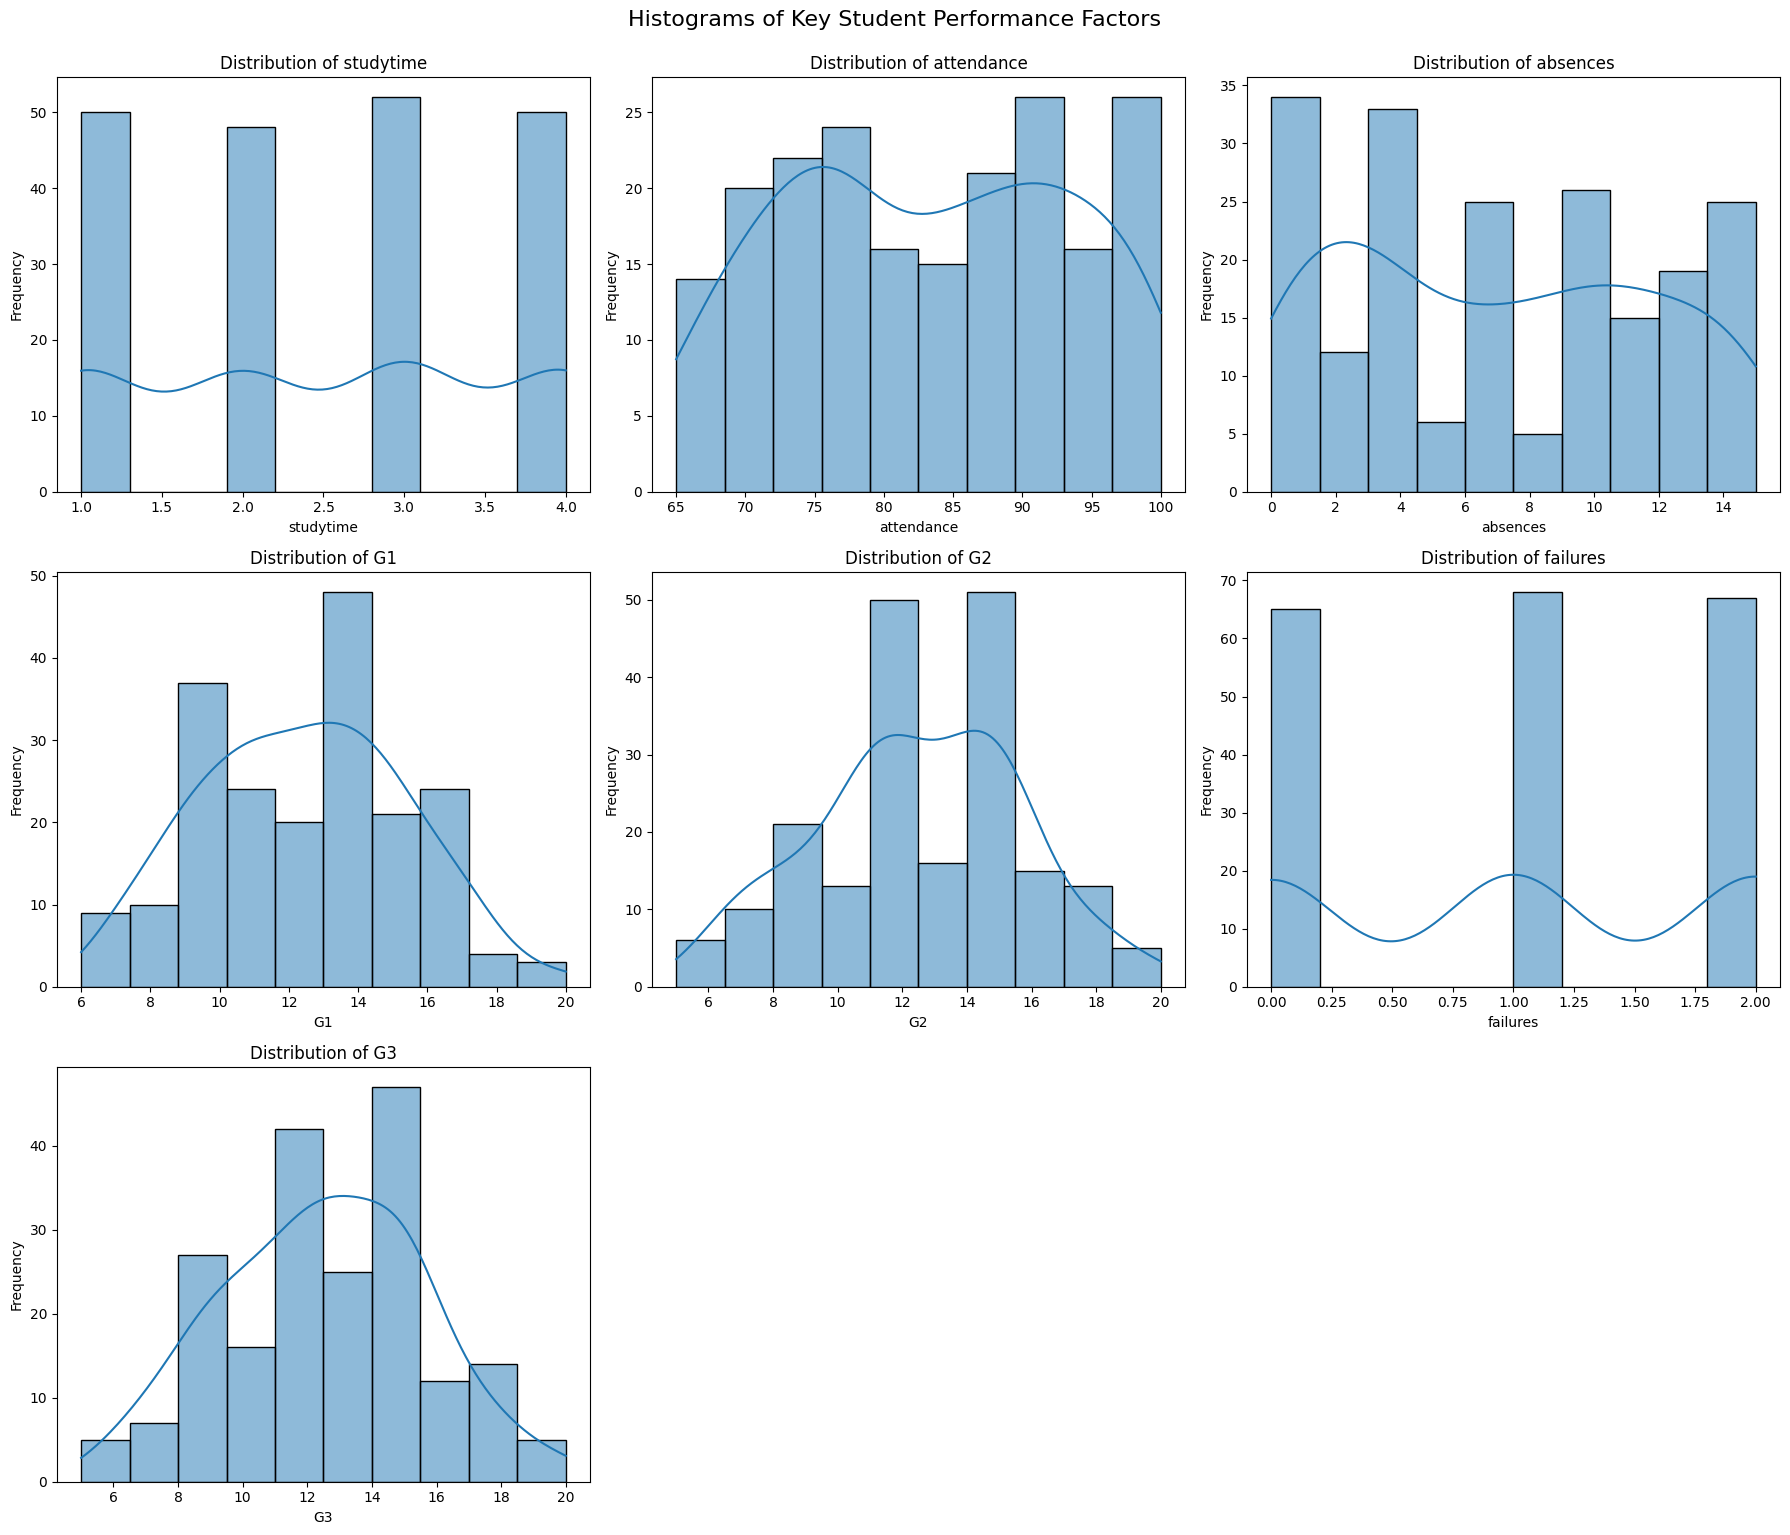

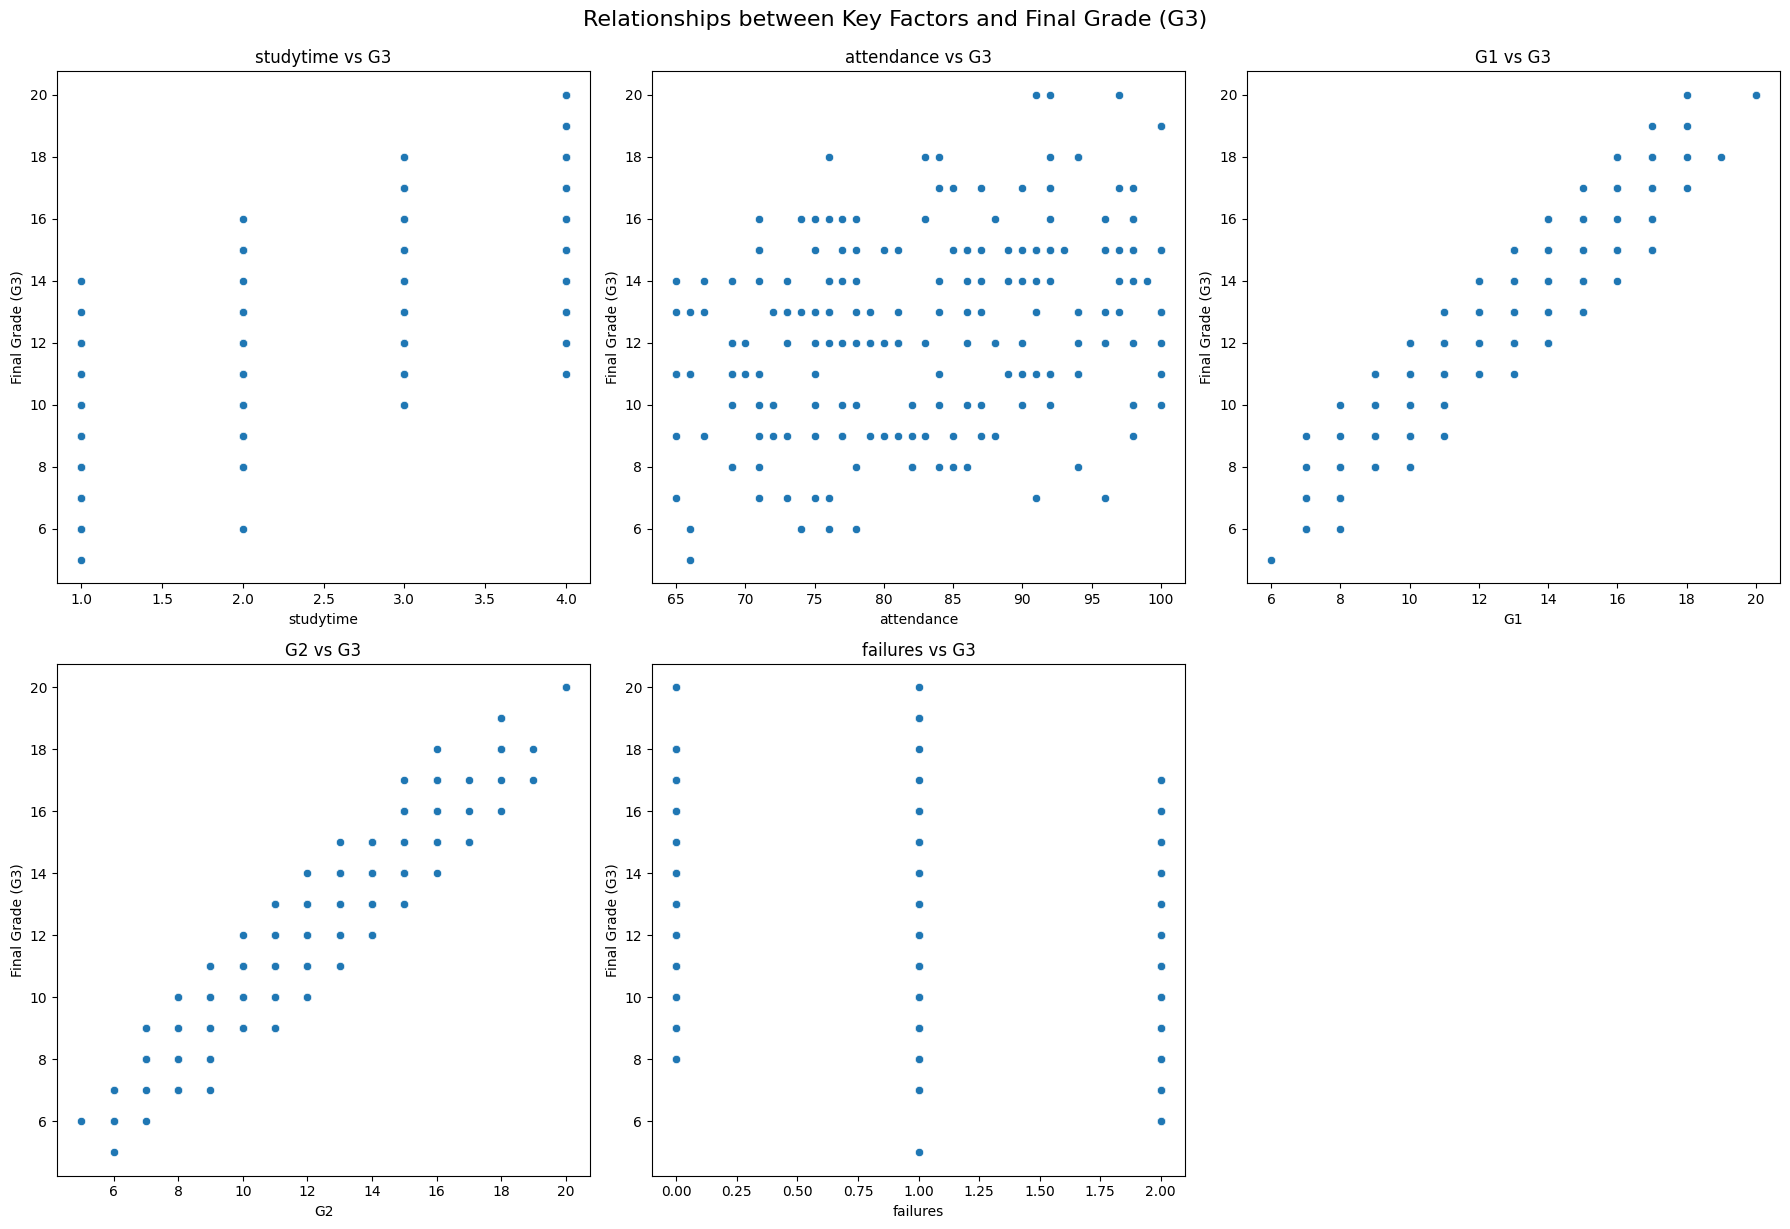

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for histograms
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# List of columns for which to plot histograms
hist_cols = ['studytime', 'attendance', 'absences', 'G1', 'G2', 'failures', 'G3']

# Plot histograms
for i, col in enumerate(hist_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=10)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(hist_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms of Key Student Performance Factors', y=1.02, fontsize=16)
plt.show()

# Set up the figure and axes for scatter plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# List of columns for which to plot scatter plots against G3
scatter_cols = ['studytime', 'attendance', 'G1', 'G2', 'failures']

# Plot scatter plots
for i, col in enumerate(scatter_cols):
    sns.scatterplot(x=df[col], y=df['G3'], ax=axes[i])
    axes[i].set_title(f'{col} vs G3')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Final Grade (G3)')

# Hide any unused subplots
for j in range(len(scatter_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Relationships between Key Factors and Final Grade (G3)', y=1.02, fontsize=16)
plt.show()

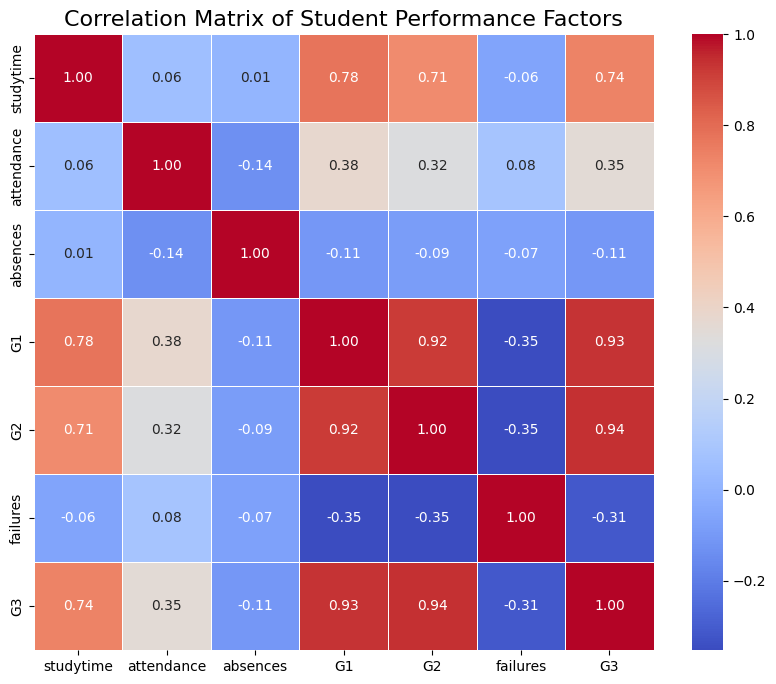

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Student Performance Factors', fontsize=16)
plt.show()

#Data for Clustering


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a new DataFrame with relevant features for clustering
df_clustering = df[['studytime', 'attendance', 'absences', 'G1', 'G2', 'failures']].copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the clustering features
scaled_features = scaler.fit_transform(df_clustering)

print("First 5 rows of df_clustering:")
print(df_clustering.head())

print("\nShape of scaled_features:", scaled_features.shape)
print("First 5 rows of scaled_features (as a NumPy array):\n", scaled_features[:5])

First 5 rows of df_clustering:
   studytime  attendance  absences  G1  G2  failures
0          1          94         1  11  11         2
1          1          76         6  11  12         0
2          3          69        14  10  11         2
3          1          79         6  12  13         0
4          3          81         2  15  14         1

Shape of scaled_features: (200, 6)
First 5 rows of scaled_features (as a NumPy array):
 [[-1.35063909  1.05984709 -1.25238417 -0.48662874 -0.47362368  1.21869809]
 [-1.35063909 -0.69116233 -0.20524022 -0.48662874 -0.16202915 -1.24331825]
 [ 0.43828686 -1.37211044  1.47019011 -0.82574284 -0.47362368  1.21869809]
 [-1.35063909 -0.39932743 -0.20524022 -0.14751464  0.14956537 -1.24331825]
 [ 0.43828686 -0.20477082 -1.04295538  0.86982768  0.4611599  -0.01231008]]


## Unsupervised Clustering (K-Means)


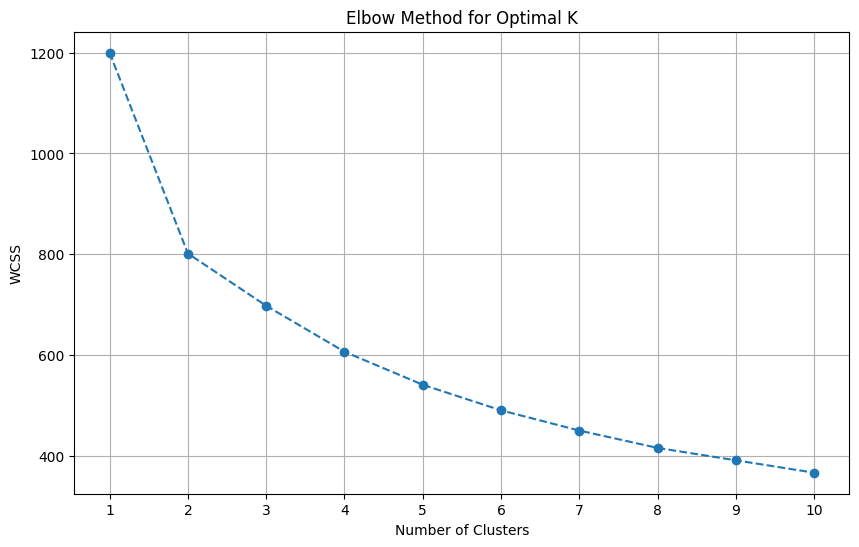

Elbow method plot displayed. Please visually determine the optimal number of clusters from the plot.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Implement the Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Elbow method plot displayed. Please visually determine the optimal number of clusters from the plot.")

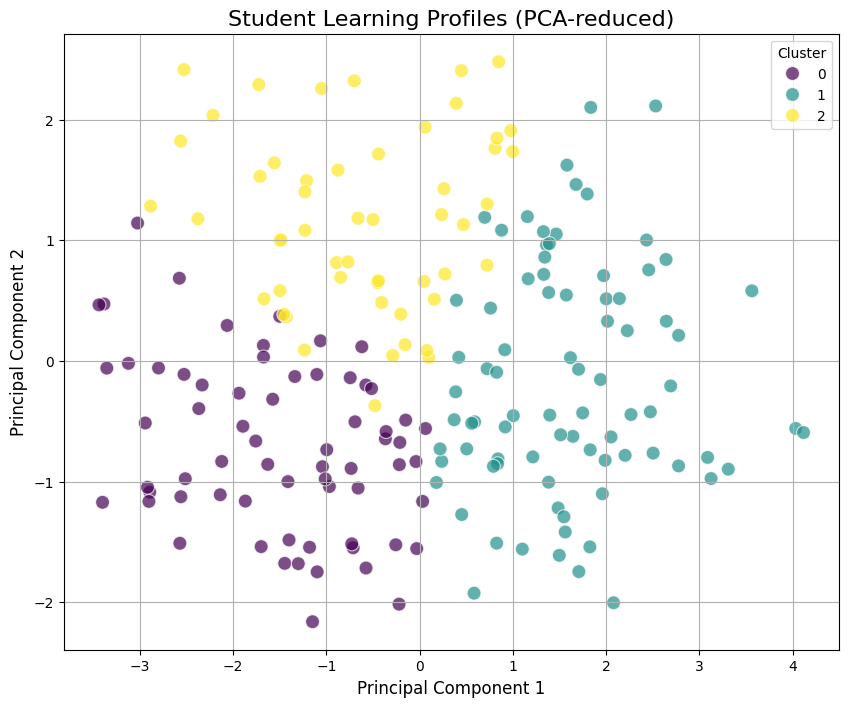

K-Means clustering applied, PCA for visualization, and clusters plotted.


In [ ]:
optimal_k = 3 # Visually determined from the elbow plot

# Apply K-Means clustering with the optimal_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels as a new column to the original df DataFrame
df['Cluster'] = clusters

# Reduce the dimensionality of scaled_features for visualization using PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Create a new DataFrame, df_pca, from pca_features
df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])

# Add the 'Cluster' column from the df DataFrame to df_pca
df_pca['Cluster'] = df['Cluster']

# Visualize the clusters in 2D using the PCA-transformed data
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100, alpha=0.7)
plt.title('Student Learning Profiles (PCA-reduced)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("K-Means clustering applied, PCA for visualization, and clusters plotted.")

## Label and Characterize Clusters

In [ ]:
cluster_means = df.groupby('Cluster').mean()
print("Mean characteristics of each cluster:")
print(cluster_means)

Mean characteristics of each cluster:
         studytime  attendance   absences         G1         G2  failures  \
Cluster                                                                     
0         1.787879   82.560606   5.378788   9.878788   9.606061  1.712121   
1         3.402439   87.841463   5.987805  15.231707  15.341463  0.804878   
2         2.019231   76.326923  10.576923  11.269231  11.769231  0.442308   

                G3  
Cluster             
0         9.803030  
1        15.292683  
2        11.538462  


### Cluster Characterization and Labeling

Based on the mean characteristics for each cluster, we can interpret their profiles as follows:

*   **Cluster 0 (Struggling Learners)**:
    *   **Study Time**: Moderate (1.79)
    *   **Attendance**: Good (82.56%)
    *   **Absences**: Moderate (5.38)
    *   **Past Grades (G1, G2)**: Low (approx. 9.88, 9.61)
    *   **Failures**: High (1.71)
    *   **Final Grade (G3)**: Low (9.80)
    *   *Interpretation*: These students show moderate study effort and good attendance but struggle with past grades and have a high number of failures, leading to low final grades.

*   **Cluster 1 (High Achievers)**:
    *   **Study Time**: High (3.40)
    *   **Attendance**: Very High (87.84%)
    *   **Absences**: Moderate (5.99)
    *   **Past Grades (G1, G2)**: Very High (approx. 15.23, 15.34)
    *   **Failures**: Low (0.80)
    *   **Final Grade (G3)**: Very High (15.29)
    *   *Interpretation*: This group demonstrates strong academic engagement, high study time, excellent attendance, and consistently high grades with few failures, resulting in top final exam scores.

*   **Cluster 2 (Inconsistent Learners)**:
    *   **Study Time**: Moderate (2.02)
    *   **Attendance**: Lower (76.33%)
    *   **Absences**: High (10.58)
    *   **Past Grades (G1, G2)**: Moderate (approx. 11.27, 11.77)
    *   **Failures**: Very Low (0.44)
    *   **Final Grade (G3)**: Moderate (11.54)
    *   *Interpretation*: These students have moderate study habits and grades but show lower attendance and a higher number of absences. Despite this, they tend to have very few past failures, suggesting potential but inconsistent engagement or external factors influencing attendance.

## Data for Supervised Learning



In [ ]:
from sklearn.model_selection import train_test_split

# Create the binary 'Pass_Fail' target variable
df['Pass_Fail'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# Define the feature set (X) and target variable (y)
X = df[['studytime', 'attendance', 'absences', 'G1', 'G2', 'failures', 'Cluster']]
y = df['Pass_Fail']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X_train:\n", X_train.head())
print("\nFirst 5 rows of y_train:\n", y_train.head())

Shape of X_train: (160, 7)
Shape of X_test: (40, 7)
Shape of y_train: (160,)
Shape of y_test: (40,)

First 5 rows of X_train:
      studytime  attendance  absences  G1  G2  failures  Cluster
79           2          72        10  10   8         2        0
197          1          83        12   9  11         1        2
38           4          84        11  14  13         2        1
24           4         100        13  15  14         1        1
122          4          92         4  15  15         1        1

First 5 rows of y_train:
 79     1
197    0
38     1
24     1
122    1
Name: Pass_Fail, dtype: int64


## Logistic Regression Model




In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Logistic Regression Model Performance:
Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       0.91      0.97      0.94        32

    accuracy                           0.90        40
   macro avg       0.87      0.80      0.83        40
weighted avg       0.90      0.90      0.89        40



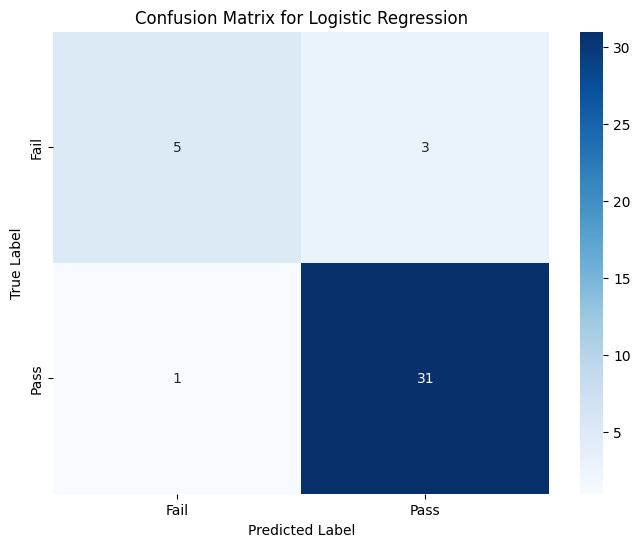

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate and print evaluation metrics
print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

# Display the confusion matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


##  Random Forest Model



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Random Forest Model Performance:
Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       1.00      0.91      0.95        32

    accuracy                           0.93        40
   macro avg       0.86      0.95      0.90        40
weighted avg       0.95      0.93      0.93        40



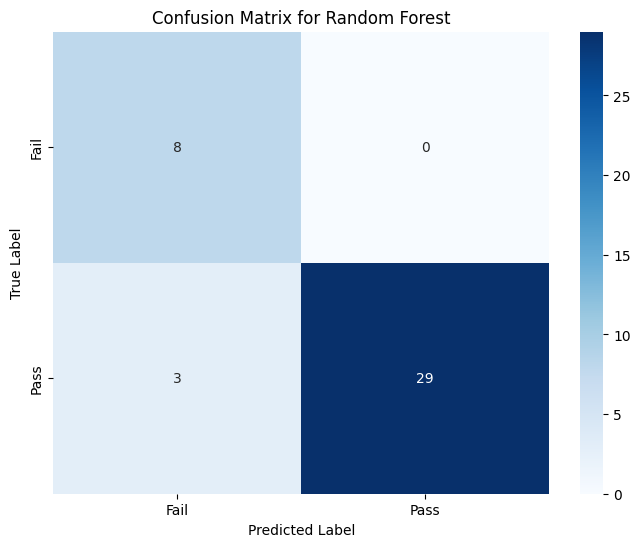

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate and print evaluation metrics
print("Random Forest Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Summary of Findings


### Analysis Summary:

**1. Exploratory Data Analysis (EDA):**

*   **Study Time**: The distribution showed varying study times among students, with a general positive correlation with 'G3' (final grade), indicating that more study time tends to lead to better grades.
*   **Attendance**: High attendance generally correlated positively with 'G3', suggesting its importance for academic success. However, some students with good attendance still showed lower grades, indicating other contributing factors.
*   **Past Grades (G1, G2)**: 'G1' and 'G2' showed a very strong positive correlation with 'G3', indicating that prior academic performance is a significant predictor of the final grade.
*   **Failures**: The number of past failures ('failures') had a strong negative correlation with 'G3', as expected.

**2. Unsupervised K-Means Clustering (Student Learning Profiles):**

*   **Cluster 0 (Struggling Learners)**: Characterized by moderate study time and good attendance, but low past grades, high failures, and consequently low final grades. This group might benefit from targeted academic support and intervention programs.
*   **Cluster 1 (High Achievers)**: Demonstrated high study time, very high attendance, consistently high past grades, few failures, and excellent final grades. These students are likely self-motivated and performing well.
*   **Cluster 2 (Inconsistent Learners)**: Showed moderate study habits and grades, but notably lower attendance and higher absences, yet very few past failures. This suggests that attendance issues might be a key area for intervention, potentially external factors affecting their presence.

**3. Predictive Model Performance (Logistic Regression vs. Random Forest for Pass/Fail Prediction):**

*   **Logistic Regression Model**: Achieved an accuracy of 0.90. It showed good precision (0.91) and recall (0.97) for predicting 'Pass' (class 1), but struggled more with 'Fail' predictions (precision 0.83, recall 0.62). The confusion matrix indicated 3 false negatives (predicted Fail, but actually Pass) and 1 false positive (predicted Pass, but actually Fail).

*   **Random Forest Model**: Achieved a higher accuracy of 0.925. It demonstrated excellent precision (1.00) and recall (0.91) for 'Pass' predictions, and significantly better recall (1.00) for 'Fail' predictions compared to Logistic Regression, with a precision of 0.73 for 'Fail'. The confusion matrix showed 3 false negatives (predicted Fail, but actually Pass) and no false positives (predicted Pass, but actually Fail). This means it correctly identified all students who failed.

**Key Takeaways and Implications for Educational Institutions:**

*   **Influential Factors**: Past grades (G1, G2), study time, and attendance are highly influential factors in predicting student success. Failures in previous courses are also strong indicators of future struggle.
*   **Learning Patterns**: The clustering analysis revealed distinct student profiles. Identifying these profiles can help institutions tailor interventions. For example, 'Struggling Learners' need comprehensive academic support, while 'Inconsistent Learners' might require focused attention on attendance issues.
*   **Model Performance**: The Random Forest model generally outperformed Logistic Regression, particularly in identifying students who would fail (perfect recall for the 'Fail' class in the test set). This is crucial for early intervention programs, as it minimizes the risk of overlooking at-risk students.
*   **Actionable Insights**: By using these models, educational institutions can proactively identify students at risk of failing the final exam. Targeted support programs can then be implemented, focusing on improving study habits, attendance, and addressing underlying issues contributing to poor past performance. The clustering results further refine these interventions by grouping students with similar challenges and strengths.

## Compare Model Performance



Model Performance Comparison:
                 Model  Accuracy  Precision_Fail  Recall_Fail   F1_Fail  \
0  Logistic Regression     0.900        0.833333        0.625  0.714286   
1        Random Forest     0.925        0.727273        1.000  0.842105   

   Precision_Pass  Recall_Pass   F1_Pass  
0        0.911765      0.96875  0.939394  
1        1.000000      0.90625  0.950820  


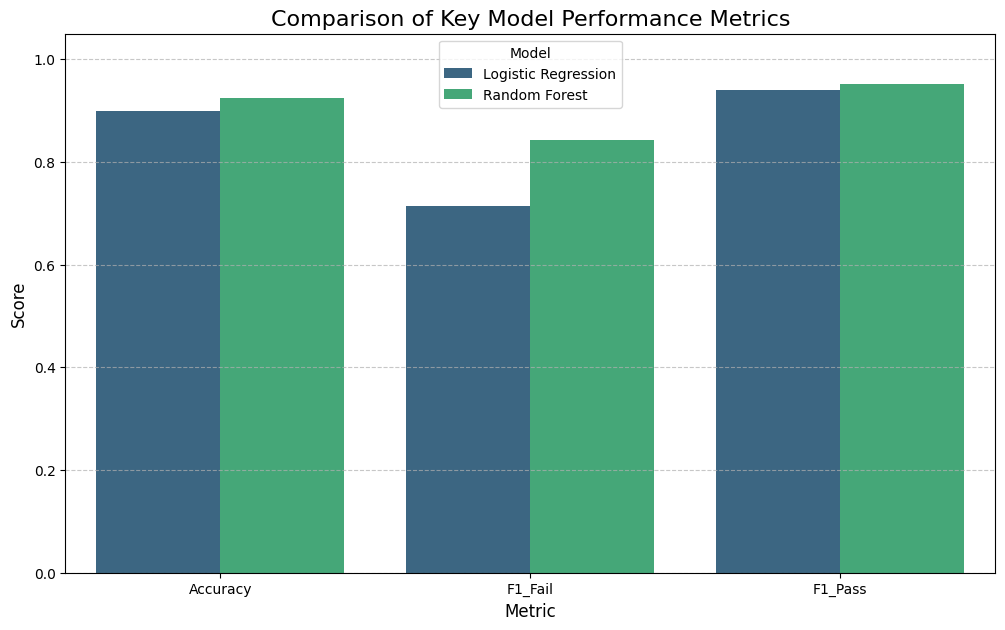

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get classification reports for both models
report_log_reg = classification_report(y_test, y_pred_log_reg, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Extract key metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [report_log_reg['accuracy'], report_rf['accuracy']],
    'Precision_Fail': [report_log_reg['0']['precision'], report_rf['0']['precision']],
    'Recall_Fail': [report_log_reg['0']['recall'], report_rf['0']['recall']],
    'F1_Fail': [report_log_reg['0']['f1-score'], report_rf['0']['f1-score']],
    'Precision_Pass': [report_log_reg['1']['precision'], report_rf['1']['precision']],
    'Recall_Pass': [report_log_reg['1']['recall'], report_rf['1']['recall']],
    'F1_Pass': [report_log_reg['1']['f1-score'], report_rf['1']['f1-score']]
}

comparison_df = pd.DataFrame(metrics_data)

print("\nModel Performance Comparison:")
print(comparison_df)

# Prepare data for visualization
plot_data = comparison_df.set_index('Model').stack().reset_index()
plot_data.columns = ['Model', 'Metric', 'Value']

# Filter for key metrics to visualize
key_metrics_to_plot = ['Accuracy', 'F1_Fail', 'F1_Pass']
plot_data_filtered = plot_data[plot_data['Metric'].isin(key_metrics_to_plot)]

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='Model', data=plot_data_filtered, palette='viridis')
plt.title('Comparison of Key Model Performance Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05) # Metrics are typically between 0 and 1
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Data Quality**: The dataset was successfully loaded and found to be complete, with no missing values, comprising 200 entries and 7 integer-type columns including 'studytime', 'attendance', 'absences', 'G1', 'G2', 'failures', and 'G3'.
*   **Influential Factors on Final Grades (G3)**:
    *   **Past Grades ('G1' and 'G2')** showed a very strong positive correlation with 'G3', indicating that prior academic performance is a primary predictor of final exam outcomes.
    *   **Study Time** and **Attendance** generally correlated positively with 'G3', suggesting their importance for academic success.
    *   **Failures** in previous courses had a strong negative correlation with 'G3', as expected.
*   **Student Learning Patterns (K-Means Clustering)**: Three distinct student learning profiles were identified using K-Means clustering, with an optimal `k=3` determined by the Elbow Method:
    *   **Struggling Learners (Cluster 0)**: Characterized by moderate study time (1.79 hours) and good attendance (82.56%), but notably low past grades (G1: \~9.88, G2: \~9.61) and the highest number of past failures (1.71), leading to low final grades (G3: \~9.80).
    *   **High Achievers (Cluster 1)**: Demonstrated high study time (3.40 hours), very high attendance (87.84%), consistently very high past grades (G1: \~15.23, G2: \~15.34), and few failures (0.80), resulting in excellent final grades (G3: \~15.29).
    *   **Inconsistent Learners (Cluster 2)**: Showed moderate study habits (2.02 hours) and grades (G1: \~11.27, G2: \~11.77, G3: \~11.54), but suffered from the lowest attendance (76.33%) and highest absences (10.58). Despite this, they had the lowest number of past failures (0.44), suggesting potential hampered by attendance issues.
*   **Predictive Model Performance (Pass/Fail Prediction)**:
    *   **Logistic Regression** achieved an accuracy of 0.90, with an F1-score of 0.714 for 'Fail' predictions and 0.939 for 'Pass' predictions. Its recall for the 'Fail' class was 0.62.
    *   **Random Forest** outperformed Logistic Regression with an accuracy of 0.925. It achieved an F1-score of 0.842 for 'Fail' predictions and 0.951 for 'Pass' predictions. Critically, the Random Forest model achieved perfect recall (1.00) for the 'Fail' class on the test set, meaning it correctly identified all students who would fail.

### Insights or Next Steps

*   **Implement Targeted Interventions**: Educational institutions can leverage the identified student clusters (Struggling Learners, High Achievers, Inconsistent Learners) to design and deploy targeted support programs. For instance, 'Struggling Learners' could benefit from academic tutoring and remedial classes, while 'Inconsistent Learners' might need interventions focusing on attendance improvement and addressing external factors affecting their presence.
*   **Proactive Risk Identification**: The Random Forest model, with its superior ability to predict student failures (100% recall for the 'Fail' class in the test set), can be integrated into an early warning system. This allows educators to proactively identify at-risk students before final exams and provide timely support, potentially altering their academic trajectory.
